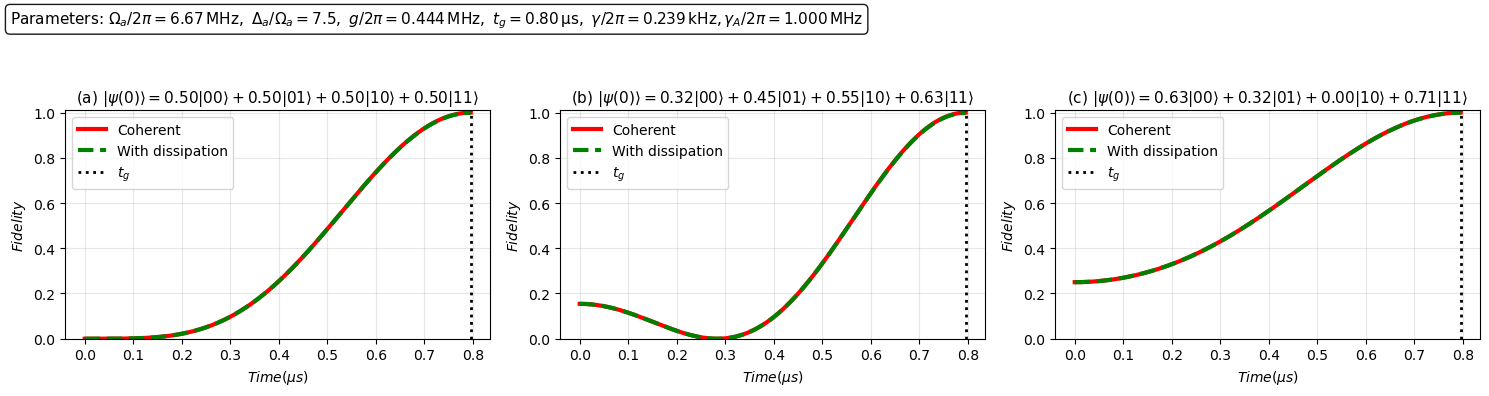

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [14]:

# ========================================================================================================================================================================================
# 1. 保真度计算
# ========================================================================================================================================================================================
import numpy as np
import matplotlib.pyplot as plt
from qutip import * #quantum tools in python
from IPython import *
from IPython.display import display, Math

# ============================================================
# 1.1参数设置
# ============================================================

Omega_a = 2 * np.pi * (20 / 3) # Rabi频率，单位MHz，转换为角频率(参考2016 S.L Su)
Omega_b = 1.2 * Omega_a # Rabi频率，单位MHz，转换为角频率(参考2016 S.L Su)
Delta_a = (15 / 2) * Omega_a #大失谐条件
Delta_b = Delta_a * (Omega_b**2) / (Omega_a**2) #比例关系

V = 2 * Delta_a - (3*Omega_a**2) / (4 * Delta_a) #RII V应满足的关系(求解出来的)

gamma =1.5e-3 #1.5e-3 MHz(参考2016 S.L Su)
gamma_A = 2 * np.pi #2pi MHz(参考2016 S.L Su)

g = Omega_a**2 / (2 * Delta_a) #Heff中耦合强度g
t_g = np.sqrt(2) * np.pi * Delta_a / (Omega_a**2) #计算得到的CNOT门实现时间

# ============================================================
# 1.2 基矢|00>...|rr>定义，张量积
# ============================================================

N = 4
i0, i1, iA, ir = 0, 1, 2, 3

psi_00 = tensor(basis(N, i0), basis(N, i0))
psi_01 = tensor(basis(N, i0), basis(N, i1))
psi_10 = tensor(basis(N, i1), basis(N, i0))
psi_11 = tensor(basis(N, i1), basis(N, i1))
psi_rr = tensor(basis(N, ir), basis(N, ir))

# ============================================================
# 1.3 有效哈密顿量(论文中计算得到)
# ============================================================

H_eff = g * (
    psi_10 * psi_rr.dag() +
    psi_11 * psi_rr.dag() +
    psi_rr * psi_10.dag() +
    psi_rr * psi_11.dag()
)

# ============================================================
# 1.4 Lindblad 算符(查阅了Qutip文档后，按照其标准形式定义)
# ============================================================

c_ops = []

#原子1的Lindblad算符
c_ops += [
    np.sqrt(gamma)   * tensor(basis(N, i0) * basis(N, ir).dag(), qeye(N)),
    np.sqrt(gamma)   * tensor(basis(N, i1) * basis(N, ir).dag(), qeye(N)),
    np.sqrt(gamma_A) * tensor(basis(N, i0) * basis(N, iA).dag(), qeye(N)),
    np.sqrt(gamma_A) * tensor(basis(N, i1) * basis(N, iA).dag(), qeye(N)),
]

#原子2的Lindblad算符
c_ops += [
    np.sqrt(gamma)   * tensor(qeye(N), basis(N, i0) * basis(N, ir).dag()),
    np.sqrt(gamma)   * tensor(qeye(N), basis(N, i1) * basis(N, ir).dag()),
    np.sqrt(gamma_A) * tensor(qeye(N), basis(N, i0) * basis(N, iA).dag()),
    np.sqrt(gamma_A) * tensor(qeye(N), basis(N, i1) * basis(N, iA).dag()),
]

# ============================================================
# 1.5 理想相位修正CNOT门(返回的是理想相位修正CNOT门作用后的态即U_cnot_correct|state>)，
# ============================================================
# 因为本方案实现的矩阵是
# [0,1,0,0//
# 0,0,1,0//
# 0,0,0,-1;
# 0,0,-1,0]
#所以需要相位修正


def ideal_cnot(state):
    psi_cnot = (
        (psi_00.dag() * state) * psi_00 +
        (psi_01.dag() * state) * psi_01 +
        (psi_10.dag() * state) * psi_11 +
        (psi_11.dag() * state) * psi_10
    )

    psi_corrected = (
        psi_00*psi_00.dag()*psi_cnot +
        psi_01*psi_01.dag()*psi_cnot -
        psi_10*psi_10.dag()*psi_cnot -
        psi_11*psi_11.dag()*psi_cnot
    )#修正后的CNOT门

    return psi_corrected #返回的是理想相位修正CNOT门作用后的态即U_cnot_correct|state>

# ============================================================
# 1.6 初始态分量系数对应a,b,c三图
# ============================================================

initial_states = [
    (0.5, 0.5, 0.5, 0.5),
    (np.sqrt(0.1), np.sqrt(0.2), np.sqrt(0.3), np.sqrt(0.4)),
    (np.sqrt(0.4),np.sqrt(0.1), 0, np.sqrt(0.5)),
    
]

# ============================================================
# 1.7 演化时间轴
# ============================================================

t_list = np.linspace(0, t_g, 201)

# ============================================================
# 1.8 作图
# ============================================================

# 创建一个1行3列的子图，用于分别绘制三种初始态下的保真度演化
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# -------- 参数说明--------
# 在图的左上角添加参数说明文本框，包含主要物理参数
fig.text(
    0.01, 0.98,
    r"Parameters: "
    r"$\Omega_a/2\pi = %.2f\,\mathrm{MHz},\ "
    r"\Delta_a/\Omega_a = %.1f,\ "
    r"g/2\pi = %.3f\,\mathrm{MHz},\ "
    r"t_g = %.2f\,\mathrm{\mu s},\ "
    r"\gamma/2\pi = %.3f\,\mathrm{kHz},"
    r"\gamma_A/2\pi = %.3f\,\mathrm{MHz}$"
    % (
        Omega_a/(2*np.pi),
        Delta_a/Omega_a,
        g/(2*np.pi),
        t_g,
        gamma/(2*np.pi)*1e3,
        gamma_A/(2*np.pi)
    ),
    ha="left", va="top", fontsize=11,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

# 遍历三组初始态参数，分别计算并绘制每种初始态下的保真度演化
for idx, (a, b, c, d) in enumerate(initial_states): # a,b,c,d为初始态分量系数

    # 构造初始态并归一化
    psi0 = (a*psi_00 + b*psi_01 + c*psi_10 + d*psi_11).unit()
    # 计算理想相位修正CNOT门作用下的目标态，即调用ideal_cnot函数
    psi_ideal = ideal_cnot(psi0)

    # 1.有耗散情况下的主方程演化
    result_diss = mesolve(H_eff, psi0, t_list, c_ops, []) #返回的是ρ(t)序列

    # 计算每个时刻的保真度（密度矩阵与理想目标态的重叠）即F(t)=<psi_ideal|rho|psi_ideal>
    fidelity_diss = [
        expect(psi_ideal * psi_ideal.dag(), rho)
        for rho in result_diss.states
    ]

    # 2.无耗散（纯相干）情况下的主方程演化，相当于冯诺依曼方程，也相当于薛定谔方程
    result_coh = mesolve(H_eff, psi0, t_list, [], []) #返回的是|psi(t)>序列

    # 计算每个时刻的保真度F(t)=|<psi_ideal|psi(t)>|^2
    fidelity_coh = []
    for psi in result_coh.states:

        overlap = psi_ideal.dag() * psi #  内积<psi_ideal|psi(t)>

        if hasattr(overlap, "full"):
            val = overlap.full().item() #如果是Qobj矩阵类型，转换为复数标量，这个玩意是QuTip库独有的，不清楚怎么回事，得用full().item().转换为Numpy数组
        else:
            val = overlap               #如果已经是复数标量，直接赋值
        fidelity_coh.append(abs(val)**2) #然后计算每个时刻F(t)=|<psi_ideal|psi(t)>|^2放入相干度矩阵中

    # 绘制当前初始态下的保真度曲线
    ax = axes[idx]
    ax.plot(t_list, fidelity_coh, 'r-', lw=3, label='Coherent', alpha=1)  # 无耗散的
    ax.plot(t_list, fidelity_diss, 'g--', lw=3, label='With dissipation', alpha=1)  # 有耗散的
    ax.axvline(t_g, color='k', ls=':', lw=2, label=r"$t_g$")  # 门操作时间的竖线

    # 设置子图标题，显示初始态信息
    ax.set_title(
        r"(%s) $|\psi(0)\rangle = %.2f|00\rangle + %.2f|01\rangle"
        r" + %.2f|10\rangle + %.2f|11\rangle$"
        % (chr(97+idx), a, b, c, d),
        fontsize=11
    )

    ax.set_xlabel(r"$Time (\mu s)$")  # 横坐标标签
    ax.set_ylabel(r"$Fidelity$")   # 纵坐标标签
    ax.set_ylim(0, 1.01)        # 保真度范围
    ax.grid(alpha=0.3)          # 网格线
    ax.legend()                 # 图例

    # -------- 初态系数标注 --------
    # 可选：在每幅图上添加初始态的详细标注
    state_text = (
        r"$|\psi(0)\rangle=$" "\n"
        r"$%.2f|00\rangle + %.2f|01\rangle$" "\n"
        r"$+\,%.2f|10\rangle + %.2f|11\rangle$"
        % (a, b, c, d)
    )



# 调整子图布局，避免重叠
plt.tight_layout(rect=[0, 0, 1, 0.82])

plt.show()

# 输出每种初始态在门操作时间 t_g 时的保真度（有耗散）
display(Math(r"\text{Fidelity at gate time } t_g \text{ (with dissipation):}"))

for idx, (a, b, c, d) in enumerate(initial_states):
    psi0 = (a*psi_00 + b*psi_01 + c*psi_10 + d*psi_11).unit()
    psi_ideal = ideal_cnot(psi0)
    result = mesolve(H_eff, psi0, [0,t_g], c_ops)
    F = fidelity(psi_ideal, result.states[-1])
    display(Math(fr"({chr(97+idx)})\quad F(t_g) = {F:.6f}"))



<IPython.core.display.Math object>

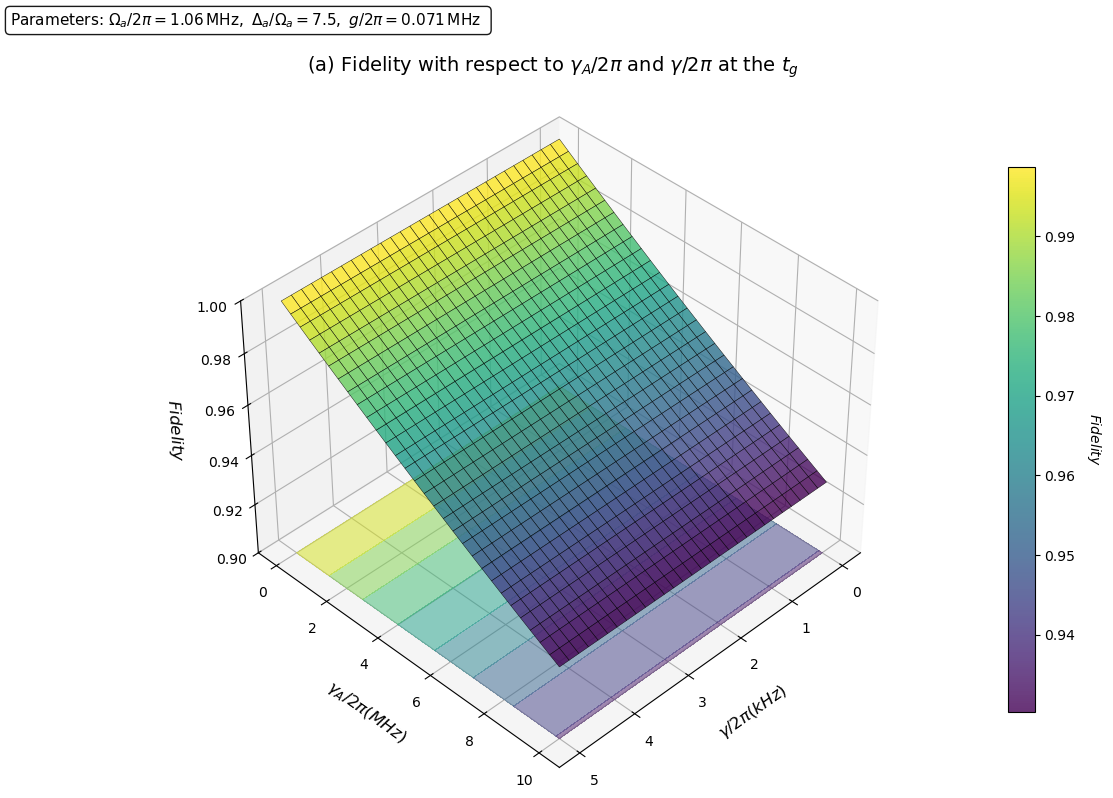

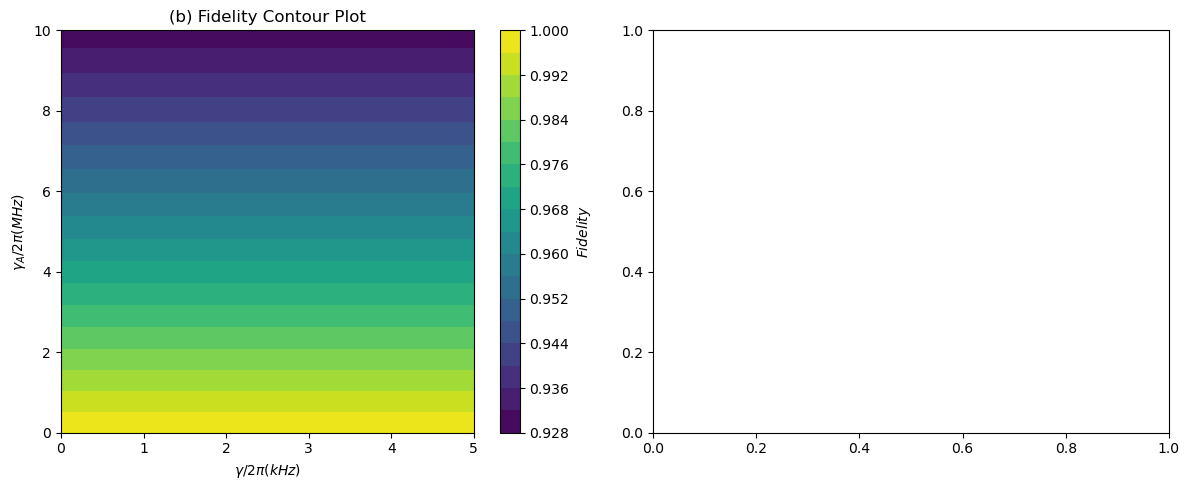

In [ ]:
# ========================================================================================================================================================================
# 2. 三维保真度图gamma和gamma_A变化对Fidelity的影响曲面图
# ========================================================================================================================================================================

# ============================================================
# 2.1 定义参数扫描范围
# ============================================================
# 注意：MHz和kHz，需要转换
Omega_a = 20/3 # Rabi频率，单位MHz，转换为角频率(参考2016 S.L Su)
Omega_b = 1.2 * Omega_a # Rabi频率，单位MHz，转换为角频率(参考2016 S.L Su)
Delta_a = (15 / 2) * Omega_a #大失谐条件(50MHz)(参考2016 S.L Su)
Delta_b = Delta_a * (Omega_b**2) / (Omega_a**2) #比例关系

gamma_A_over2pi = np.linspace(0, 10, 30)  # γ_A/2π，单位：MHz (0-10 MHz)
gamma_over2pi = np.linspace(0, 5, 30)    # γ/2π，单位：kHz (0-10 kHz)

# 转换为角频率
gamma_A_vals = gamma_A_over2pi * 2 * np.pi  # γ_A单位(MHz)
gamma_vals = gamma_over2pi * 1e-3 * 2 * np.pi  # γ从kHz转换为MHz(1kHz=1e-3 MHz)

g= Omega_a**2 / (2 * Delta_a) #Heff中耦合强度g
H_eff = g * (
    psi_10 * psi_rr.dag() +
    psi_11 * psi_rr.dag() +
    psi_rr * psi_10.dag() +
    psi_rr * psi_11.dag()
)


t_list = np.linspace(0, t_g, 201)
# ============================================================
# 2.2 定义计算单个保真度的函数
# ============================================================
def calculate_fidelity_for_params(gamma_val, gamma_A_val,H_eff=H_eff, initial_states=initial_states,t_g=t_g):
    #计算特定γ和γ_A参数下的保真度
    (a, b, c, d) =initial_states[0] #选择初始态系数为第{0+1}个初始态
    psi0 = (a*psi_00 + b*psi_01 + c*psi_10 + d*psi_11).unit()
    psi_ideal = ideal_cnot(psi0)
    
    # 根据新的γ和γ_A值重新创建Lindblad算符
    c_ops_local = []
    
    # 原子1的L算符
    c_ops_local += [
        np.sqrt(gamma_val)   * tensor(basis(N, i0) * basis(N, ir).dag(), qeye(N)),
        np.sqrt(gamma_val)   * tensor(basis(N, i1) * basis(N, ir).dag(), qeye(N)),
        np.sqrt(gamma_A_val) * tensor(basis(N, i0) * basis(N, iA).dag(), qeye(N)),
        np.sqrt(gamma_A_val) * tensor(basis(N, i1) * basis(N, iA).dag(), qeye(N)),
    ]
    
    # 原子2的L算符
    c_ops_local += [
        np.sqrt(gamma_val)   * tensor(qeye(N), basis(N, i0) * basis(N, ir).dag()),
        np.sqrt(gamma_val)   * tensor(qeye(N), basis(N, i1) * basis(N, ir).dag()),
        np.sqrt(gamma_A_val) * tensor(qeye(N), basis(N, i0) * basis(N, iA).dag()),
        np.sqrt(gamma_A_val) * tensor(qeye(N), basis(N, i1) * basis(N, iA).dag()),
    ]
    
    # 计算时间演化
    result = mesolve(H_eff, psi0, t_list, c_ops_local)
    
    # 计算保真度
    F = fidelity(psi_ideal, result.states[-1])
    return F

# ============================================================
# 2.3 创建三维数据网格
# ============================================================
display(Math(r"\text{绘制} \gamma-\gamma_A-\text{Fidelity曲面}"))
F_3d = np.zeros((len(gamma_vals), len(gamma_A_vals)))

# 遍历所有参数组合
for i, gamma_val in enumerate(gamma_vals):
    for j, gamma_A_val in enumerate(gamma_A_vals):
        F_3d[i, j] = calculate_fidelity_for_params(gamma_val, gamma_A_val,H_eff=H_eff, initial_states=initial_states,t_g=t_g)
#        print(f"$gamma/2\pi$={gamma_vals[i]:.1f} kHz, $gamma_A/2\pi$={gamma_A_vals[j]:.1f} MHz, F={F_3d[i,j]:.4f}")

# ============================================================
# 2.4 创建三维曲面图
# ============================================================
from operator import index
from mpl_toolkits.mplot3d import Axes3D
fig_3d = plt.figure(figsize=(12, 8))

# 在图的左上角添加参数说明文本框，包含主要物理参数
fig_3d.text(
    0.01, 0.98,
    r"Parameters: "
    r"$\Omega_a/2\pi = %.2f\,\mathrm{MHz},\ "
    r"\Delta_a/\Omega_a = %.1f,\ "
    r"g/2\pi = %.3f\,\mathrm{MHz}\ $ "

    % (
        Omega_a/(2*np.pi),
        Delta_a/Omega_a,
        g/(2*np.pi),

    ),
    ha="left", va="top", fontsize=11,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

ax_3d = fig_3d.add_subplot(111, projection='3d')

# 创建网格
GAMMA, GAMMA_A = np.meshgrid(gamma_over2pi, gamma_A_over2pi)

# 绘制曲面
surf = ax_3d.plot_surface(GAMMA, GAMMA_A, F_3d, 
                         cmap='viridis',  # 使用viridis色彩映射
                         edgecolor='k', 
                         linewidth=0.3, 
                         alpha=0.8)

# 设置视角
ax_3d.view_init(elev=40, azim=45)  # 调整视角，elev=仰角，azim=方位角

# 设置标签
ax_3d.set_xlabel('$\gamma/2\pi (kHz)$', fontsize=12, labelpad=10)
ax_3d.set_ylabel('$\gamma_A/2\pi (MHz)$', fontsize=12, labelpad=10)
ax_3d.set_zlabel('$Fidelity$', fontsize=12, labelpad=10)
ax_3d.set_title('\n\n (a) Fidelity with respect to $\gamma_A/2\pi$ and $\gamma/2\pi$ at the $t_g$', fontsize=14, pad=20)

# 添加颜色条
cbar = fig_3d.colorbar(surf, ax=ax_3d, pad=0.1, shrink=0.8)
cbar.set_label('$Fidelity$', rotation=270, labelpad=20)

# 设置Z轴Fidelity范围
ax_3d.set_zlim(0.9, 1)

# 显示网格
ax_3d.grid(True, alpha=0.5)

# ============================================================
# 2.5 绘制其等高线投影
# ============================================================
# 在底部投影等高线
ax_3d.contourf(GAMMA, GAMMA_A, F_3d, zdir='z', offset=0.90, cmap='viridis', alpha=0.5)


plt.tight_layout()
plt.show()

# ============================================================
# 2.6 保存数据
# ============================================================
#np.savez('fidelity_3d_data.npz', 
#         gamma_values=gamma_values, 
#         gamma_A_values=gamma_A_values, 
#         fidelity=F_3d)
#print("三维保真度数据已保存到 fidelity_3d_data.npz")

# ============================================================
# 2.7 绘制其二维等高线图与热图
# ============================================================

fig_2d, ax_2d = plt.subplots(1, 2, figsize=(12, 5))

# 左图：等高线
contour = ax_2d[0].contourf(GAMMA, GAMMA_A, F_3d, levels=20, cmap='viridis')
ax_2d[0].set_xlabel('$\gamma/2\pi (kHz)$')
ax_2d[0].set_ylabel('$\gamma_A/2\pi (MHz)$')

ax_2d[0].set_title('(b) Fidelity Contour Plot')
fig_2d.colorbar(contour, ax=ax_2d[0], label='$Fidelity$')

# 右图：热图
im = ax_2d[1].imshow(F_3d, extent=[0, 10, 0, 10], origin='lower', aspect='auto', cmap='viridis')
ax_2d[1].set_xlabel('$\gamma/2\pi (kHz)$')
ax_2d[1].set_ylabel('$\gamma_A/2\pi (MHz)$')

ax_2d[1].set_title('(c) Fidelity Heatmap')
fig_2d.colorbar(im, ax=ax_2d[1], label='$Fidelity$')

plt.tight_layout()
plt.show()


C:\Users\67461\AppData\Local\Temp\ipykernel_163288\975782887.py:151: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax.legend([line1, f'Max1: {fidelity_without_adjusted_tg[np.argmax(fidelity_without_adjusted_tg)]:.4f}'],
C:\Users\67461\AppData\Local\Temp\ipykernel_163288\975782887.py:151: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax.legend([line1, f'Max1: {fidelity_without_adjusted_tg[np.argmax(fidelity_without_adjusted_tg)]:.4f}'],


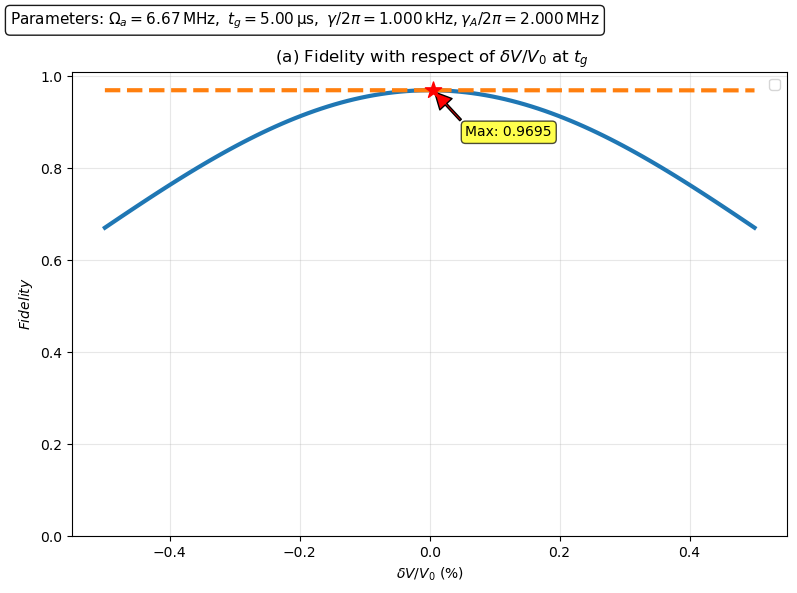

In [16]:
# ========================================================================================================================================================================================
# 3. 保真度图随δV/V变化
# ========================================================================================================================================================================================
# ============================================================
# 3.1 参数设置
# ============================================================

from math import sqrt
import numpy as np
import matplotlib.pyplot as plt
from pyparsing import line
from qutip import * #quantum tools in python
from IPython import *

Omega_a = 20/3 # Rabi频率，单位MHz，转换为角频率(参考2016 S.L Su)
Omega_b = 1.2 * Omega_a # Rabi频率，单位MHz，转换为角频率(参考2016 S.L Su)
Delta_a_0 = (15 / 2) * Omega_a #大失谐条件(50MHz)(参考2016 S.L Su)
Delta_b = Delta_a_0 * (Omega_b**2) / (Omega_a**2) #比例关系
gamma =2 * np.pi*1e-3      #2pi kHz(参考2016 S.L Su)
gamma_A = 2 * np.pi*2     #4pi MHz(参考2016 S.L Su)
t_g0 = sqrt(2) * np.pi * Delta_a_0 / Omega_a**2 #计算得到

g1 = Omega_a**2 / (2 * Delta_a_0) #Heff中耦合强度g


t_list0 = np.linspace(0, t_g0, 201) 

# 相对误差 ε = δV / V0
Eps_list = np.linspace(-0.005, 0.005, 100)

# 未扰动RRI强度
V0 = 2 * Delta_a_0 - (3 * Omega_a**2) / (4 * Delta_a_0) #由论文中RRI关系求得

# ============================================================
# 耗散算符（i0, i1, ir, iA 已定义）
# ============================================================

c_ops = []

c_ops += [
    np.sqrt(gamma)   * tensor(basis(N, i0) * basis(N, ir).dag(), qeye(N)),
    np.sqrt(gamma)   * tensor(basis(N, i1) * basis(N, ir).dag(), qeye(N)),
    np.sqrt(gamma_A) * tensor(basis(N, i0) * basis(N, iA).dag(), qeye(N)),
    np.sqrt(gamma_A) * tensor(basis(N, i1) * basis(N, iA).dag(), qeye(N)),
]

c_ops += [
    np.sqrt(gamma)   * tensor(qeye(N), basis(N, i0) * basis(N, ir).dag()),
    np.sqrt(gamma)   * tensor(qeye(N), basis(N, i1) * basis(N, ir).dag()),
    np.sqrt(gamma_A) * tensor(qeye(N), basis(N, i0) * basis(N, iA).dag()),
    np.sqrt(gamma_A) * tensor(qeye(N), basis(N, i1) * basis(N, iA).dag()),
]

# ============================================================
# 初态与理想目标态
# ============================================================

(a, b, c, d) = initial_states[0]
psi0 = (a * psi_00 + b * psi_01 + c * psi_10 + d * psi_11).unit()
psi_ideal = ideal_cnot(psi0)

# ============================================================
# Fidelity 计算
# ============================================================

fidelity_without_adjusted_tg  = []
fidelity_with_adjusted_tg = []

# ============================================================
# 未调整 Δa 满足条件V后,tg时刻的保真度计算
# ============================================================
for eps in Eps_list:

    delta_V = eps * V0

    H_eff_correct_bl = g1 * (
        psi_10 * psi_rr.dag() +
        psi_11 * psi_rr.dag() +
        psi_rr * psi_10.dag() +
        psi_rr * psi_11.dag()
    ) + delta_V * psi_rr * psi_rr.dag()

    # -------- 有耗散 --------
    result_without_adjusted = mesolve(H_eff_correct_bl, psi0, t_list0, c_ops, [])
    F_without_adjusted = expect(psi_ideal * psi_ideal.dag(),result_without_adjusted.states[-1])
    fidelity_without_adjusted_tg.append(F_without_adjusted)

# ============================================================
# 调整失谐 Δa 满足 V 后,tg时刻的保真度计算
# ============================================================
for eps in Eps_list:
    V= V0 * (1 + eps) #实际RRI
    Delta_a_adjusted = (4*V+sqrt(16*(V**2)+96*Omega_a**2))/16 #调整后的失谐
    Delta_b_adjusted = Delta_a_adjusted * (Omega_b**2) / (Omega_a**2) #调整后的失谐比例关系
    g2 = Omega_a**2 / (2 * Delta_a_adjusted) #Heff中耦合强度g

    H_eff_correct_red = g2 * (
        psi_10 * psi_rr.dag() +
        psi_11 * psi_rr.dag() +
        psi_rr * psi_10.dag() +
        psi_rr * psi_11.dag()
    )

    # -------- 有耗散，但调整失谐了 --------
    result_with_adjusted = mesolve(H_eff_correct_red, psi0, t_list0, c_ops, [])
    F_with_adjusted = expect(psi_ideal * psi_ideal.dag(),result_with_adjusted.states[-1])
    fidelity_with_adjusted_tg.append(F_with_adjusted)
# ============================================================
# 绘图
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))
# -------- 参数说明--------
# 在图的左上角添加参数说明文本框，包含主要物理参数
fig.text(
    0.01, 0.98,
    r"Parameters: "
    r"$\Omega_a = %.2f\,\mathrm{MHz},\ "
    r"t_g = %.2f\,\mathrm{\mu s},\ "
    r"\gamma/2\pi = %.3f\,\mathrm{kHz},"
    r"\gamma_A/2\pi = %.3f\,\mathrm{MHz}$"
    % (
        Omega_a,
        t_g0,
        gamma*1e3/(2*np.pi),
        gamma_A/(2*np.pi)
    ),

    ha="left", va="top", fontsize=11,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)


# 绘制曲线
line1=ax.plot(Eps_list*100, fidelity_without_adjusted_tg,
        lw=3, label=f'$\Delta_a= {Delta_a_0} MHz$')

line2=ax.plot(Eps_list*100, fidelity_with_adjusted_tg,
        lw=3, ls='--', label=f'$\Delta_a$ satisfies $V_0=2\Delta_a-3\Omega_a^2/4\Delta_a$')

# 标记最高点
ax.scatter(Eps_list[np.argmax(fidelity_without_adjusted_tg)] * 100, fidelity_without_adjusted_tg[np.argmax(fidelity_without_adjusted_tg)], color='red', s=150, zorder=5, marker='*')
ax.annotate(f'Max: {fidelity_without_adjusted_tg[np.argmax(fidelity_without_adjusted_tg)]:.4f}', 
            xy=(Eps_list[np.argmax(fidelity_without_adjusted_tg)] * 100, fidelity_without_adjusted_tg[np.argmax(fidelity_without_adjusted_tg)]), 
            xytext=(Eps_list[np.argmax(fidelity_without_adjusted_tg)] * 100+0.05, fidelity_without_adjusted_tg[np.argmax(fidelity_without_adjusted_tg)]-0.1),
            arrowprops=dict(facecolor='red', shrink=0.05, width=1.5),
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

# 只在图例中显示最高点信息
ax.legend([line1, f'Max1: {fidelity_without_adjusted_tg[np.argmax(fidelity_without_adjusted_tg)]:.4f}'],
          [f'$Δ_a= {Delta_a_0:.2f} MHz$', 
           f'$Δ_a$ satisfies $V_0=2Δ_a-3Ω_a^2/4Δ_a$',
           f'Max: {fidelity_without_adjusted_tg[np.argmax(fidelity_without_adjusted_tg)]:.4f}'])

ax.set_xlabel(r'$\delta V / V_0$ (%)')
ax.set_ylabel('$Fidelity$')

ax.set_title('\n\n (a) Fidelity with respect of $\delta V / V_0$ at $t_g$')
ax.set_ylim(0, 1.01)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()





















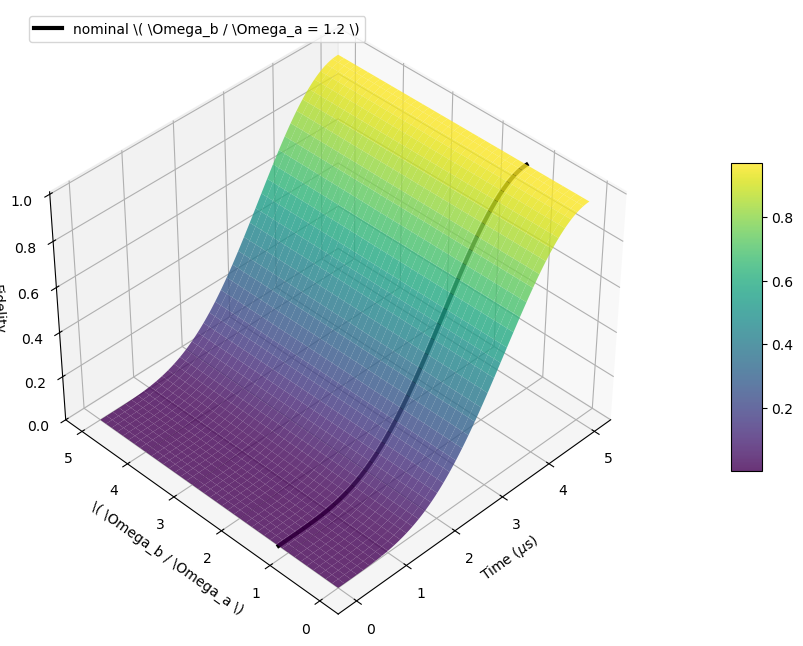

In [17]:
# ========================================================================================================================================================================================
from numpy import meshgrid
import numpy as np
import matplotlib.pyplot as plt
from qutip import * #quantum tools in python
from IPython import *
from IPython.display import display, Math

Omega_a = 20/3 # Rabi频率，单位MHz，转换为角频率(参考2016 S.L Su)
Delta_a = (15 / 2) * Omega_a #大失谐条件(50MHz)(参考2016 S.L Su)
t_g = np.sqrt(2) * np.pi * Delta_a / (Omega_a**2) #计算得到的CNOT门实现时间
t_list = np.linspace(0, t_g, 201)
Omega_b =np.linspace(0,5*Omega_a, 201) # Rabi频率，单位MHz，转换为角频率(参考2016 S.L Su)

gamma =2 * np.pi*1e-3      #2pi kHz(参考2016 S.L Su)
gamma_A = 2 * np.pi*2     #4pi MHz(参考2016 S.L Su)
# ============================================================
V = 2 * Delta_a - (3*Omega_a**2) / (4 * Delta_a) #RII V应满足的关系(求解出来的)
g = Omega_a**2 / (2 * Delta_a) #Heff中耦合强度g

# ============================================================
N = 4
i0, i1, iA, ir = 0, 1, 2, 3

psi_00 = tensor(basis(N, i0), basis(N, i0))
psi_01 = tensor(basis(N, i0), basis(N, i1))
psi_10 = tensor(basis(N, i1), basis(N, i0))
psi_11 = tensor(basis(N, i1), basis(N, i1))
psi_rr = tensor(basis(N, ir), basis(N, ir))
H_eff = g * (
    psi_10 * psi_rr.dag() +
    psi_11 * psi_rr.dag() +
    psi_rr * psi_10.dag() +
    psi_rr * psi_11.dag()
)

# ============================================================
# Lindblad 算符(查阅了Qutip文档后，按照其标准形式定义，耗散系数定义方式与原文gamma/2,gamma_A/2等价)
# ============================================================

c_ops = []

#原子1的L算符
c_ops += [
    np.sqrt(gamma)   * tensor(basis(N, i0) * basis(N, ir).dag(), qeye(N)),
    np.sqrt(gamma)   * tensor(basis(N, i1) * basis(N, ir).dag(), qeye(N)),
    np.sqrt(gamma_A) * tensor(basis(N, i0) * basis(N, iA).dag(), qeye(N)),
    np.sqrt(gamma_A) * tensor(basis(N, i1) * basis(N, iA).dag(), qeye(N)),
]

#原子2的L算符
c_ops += [
    np.sqrt(gamma)   * tensor(qeye(N), basis(N, i0) * basis(N, ir).dag()),
    np.sqrt(gamma)   * tensor(qeye(N), basis(N, i1) * basis(N, ir).dag()),
    np.sqrt(gamma_A) * tensor(qeye(N), basis(N, i0) * basis(N, iA).dag()),
    np.sqrt(gamma_A) * tensor(qeye(N), basis(N, i1) * basis(N, iA).dag()),
]

# ========================================================================================================================================================================================
# 2. 保真度 vs 时间 vs \Omega_b / \Omega_a 的三维图像（在第一段代码基础上添加，假设第一段代码已完整运行，所有变量如 H_eff、c_ops、t_list、ideal_cnot、initial_states 等已定义）
# ========================================================================================================================================================================================

# 使用第一种初始态（与原图 (a) 对应，即均匀叠加态）
initial_states = [
    (0.5, 0.5, 0.5, 0.5),
    (np.sqrt(0.1), np.sqrt(0.2), np.sqrt(0.3), np.sqrt(0.4)),
    (np.sqrt(0.4),np.sqrt(0.1), 0, np.sqrt(0.5)),
    
]

def ideal_cnot(state):
    psi_cnot = (
        (psi_00.dag() * state) * psi_00 +
        (psi_01.dag() * state) * psi_01 +
        (psi_10.dag() * state) * psi_11 +
        (psi_11.dag() * state) * psi_10
    )

    psi_corrected = (
        psi_00*psi_00.dag()*psi_cnot +
        psi_01*psi_01.dag()*psi_cnot -
        psi_10*psi_10.dag()*psi_cnot -
        psi_11*psi_11.dag()*psi_cnot
    )#修正后的CNOT门

    return psi_corrected #返回的是理想相位修正CNOT门作用后的态即U_cnot_correct|state>
    
(a, b, c, d) = initial_states[0]
psi0 = (a * psi_00 + b * psi_01 + c * psi_10 + d * psi_11).unit()
psi_ideal = ideal_cnot(psi0)

# 有耗散情况下的演化（一次性计算所有时间点的保真度）
result_diss = mesolve(H_eff, psi0, t_list, c_ops, [])
fidelity_diss = np.array([
    expect(psi_ideal * psi_ideal.dag(), rho)
    for rho in result_diss.states
])

# \Omega_b / \Omega_a 的扫描范围（0 ~ 5，与原第二段代码意图一致）
num_points = 201
omega_ratio = np.linspace(0, 5, num_points)

# 由于有效哈密顿量 H_eff 和耗散算符 c_ops 不依赖于 \Omega_b（通过比例调整 \Delta_b 保持 g 不变），
# 保真度曲线在 \Omega_b 方向上完全相同，体现对 \Omega_b 波动的高鲁棒性
F_3d0 = np.tile(fidelity_diss, (num_points, 1))  # 形状：(num_points, len(t_list))

# 网格化用于三维绘图
T, OMEGA_RATIO = np.meshgrid(t_list, omega_ratio)

# 创建三维曲面图
fig_3d = plt.figure(figsize=(12, 8))
ax_3d = fig_3d.add_subplot(111, projection='3d')

# 绘制曲面
surf = ax_3d.plot_surface(
    T, OMEGA_RATIO, F_3d0,
    cmap='viridis', alpha=0.8, linewidth=0, antialiased=True
)

# 坐标轴标签
ax_3d.view_init(elev=40, azim=45+180)  # 调整视角，elev=仰角，azim=方位角
ax_3d.set_xlabel(r'Time ($\mu$s)')
ax_3d.set_ylabel(r'\( \Omega_b / \Omega_a \)')
ax_3d.set_zlabel(r'Fidelity')
ax_3d.set_zlim(0, 1.01)

# 颜色条
fig_3d.colorbar(surf, shrink=0.5, aspect=10, pad=0.1)

# 可选：在名义值 \Omega_b / \Omega_a = 1.2 处标一条黑线（突出原参数点）
nominal_ratio = 1.2
ax_3d.plot(
    t_list, 
    np.full_like(t_list, nominal_ratio), 
    fidelity_diss, 
    color='black', linewidth=3, linestyle='-', 
    label=r'nominal \( \Omega_b / \Omega_a = 1.2 \)'
)
ax_3d.legend(loc='upper left')

# 显示图像
plt.show()